<a href="https://colab.research.google.com/github/bubai-jkc/cub_resnet50/blob/main/resnet50_leaf_disease_validation_split.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!kaggle datasets download -d fakhrealam9537/leaf-disease-segmentation-dataset
import zipfile
zip_ref = zipfile.ZipFile('/content/leaf-disease-segmentation-dataset.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

Dataset URL: https://www.kaggle.com/datasets/fakhrealam9537/leaf-disease-segmentation-dataset
License(s): CC0-1.0
 91% 460M/503M [00:00<00:00, 409MB/s]
100% 503M/503M [00:01<00:00, 460MB/s]


Epoch 1: Train Loss 0.3785 | Val Loss 0.1785 | Val IoU 0.6675
--> Saved New Best Model!


Epoch 2: Train Loss 0.1552 | Val Loss 0.1110 | Val IoU 0.7102
--> Saved New Best Model!


Epoch 3: Train Loss 0.1142 | Val Loss 0.0973 | Val IoU 0.7348
--> Saved New Best Model!


Epoch 4: Train Loss 0.0895 | Val Loss 0.0848 | Val IoU 0.7419
--> Saved New Best Model!


Epoch 5: Train Loss 0.0774 | Val Loss 0.0785 | Val IoU 0.7551
--> Saved New Best Model!


...

Epoch 36: Train Loss 0.0253 | Val Loss 0.0860 | Val IoU 0.7950


Epoch 37: Train Loss 0.0253 | Val Loss 0.0828 | Val IoU 0.8018


Epoch 38: Train Loss 0.0251 | Val Loss 0.0810 | Val IoU 0.8032


Epoch 39: Train Loss 0.0253 | Val Loss 0.0848 | Val IoU 0.7922


Epoch 40: Train Loss 0.0270 | Val Loss 0.0908 | Val IoU 0.7885


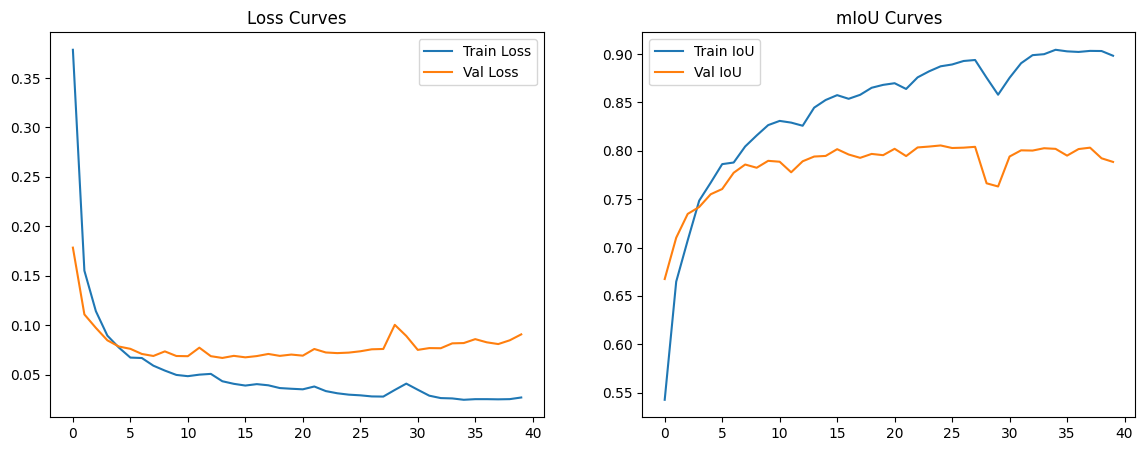

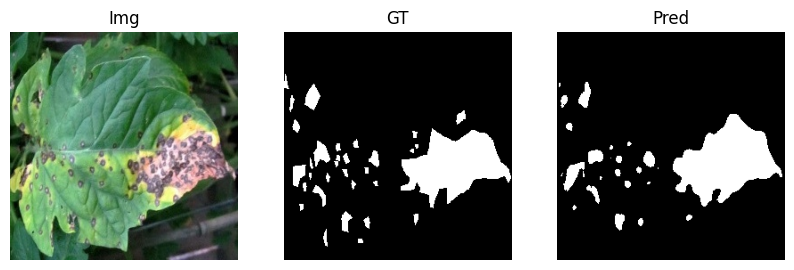

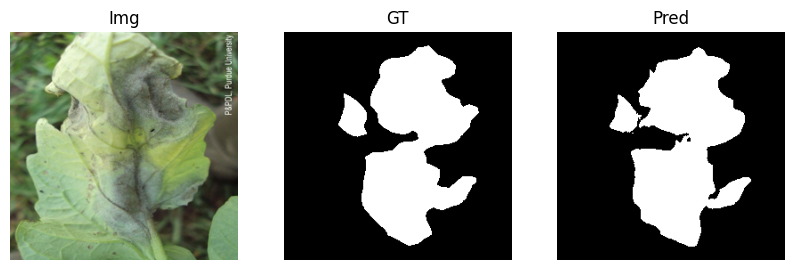

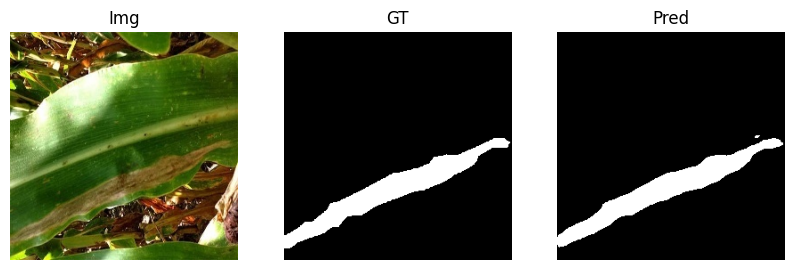

In [ ]:
import os
import zipfile
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from tqdm import tqdm



# Configuration
DATASET_PATH = "/content/aug_data/aug_data"
IMG_SIZE = (256, 256)
BATCH_SIZE = 8
LEARNING_RATE = 1e-4
NUM_EPOCHS = 40
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. DATASET WITH BEST-PRACTICE AUGMENTATIONS ---
class LeafDiseaseDataset(Dataset):
    def __init__(self, root_dir, img_size=IMG_SIZE, augment=False):
        self.images_dir = os.path.join(root_dir, "images")
        self.masks_dir  = os.path.join(root_dir, "masks")
        self.img_size = img_size
        self.image_files = sorted(os.listdir(self.images_dir))
        self.augment = augment
        self.normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path  = os.path.join(self.images_dir, img_name)
        mask_path = os.path.join(self.masks_dir, img_name.replace(".jpg", ".png"))

        image = Image.open(img_path).convert("RGB")
        mask  = Image.open(mask_path).convert("L")

        image = image.resize(self.img_size)
        mask  = mask.resize(self.img_size, resample=Image.NEAREST)

        # Apply Augmentations for Training
        if self.augment:
            if np.random.random() > 0.5:
                image = transforms.functional.hflip(image)
                mask = transforms.functional.hflip(mask)
            if np.random.random() > 0.5:
                image = transforms.functional.vflip(image)
                mask = transforms.functional.vflip(mask)
            angle = np.random.randint(-30, 30)
            image = transforms.functional.rotate(image, angle)
            mask = transforms.functional.rotate(mask, angle)

        image = transforms.ToTensor()(image)
        image = self.normalize(image)

        mask = transforms.ToTensor()(mask)
        mask = (mask > 0).float()

        return image, mask

# Create Split (75% Train, 25% Val)
full_dataset = LeafDiseaseDataset(DATASET_PATH, augment=True)
train_size = int(0.75 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Disable augmentation for the validation set
val_dataset.dataset.augment = False

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# --- 3. MODEL ARCHITECTURE (RESNET50-UNET) ---
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_ch // 2 + skip_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)

class ResNet50UNet(nn.Module):
    def __init__(self, n_classes=1):
        super().__init__()
        base_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        base_layers = list(base_model.children())

        # Encoder - ResNet50 Stages
        self.init_conv = nn.Sequential(*base_layers[:3])
        self.pool = base_layers[3]
        self.layer1 = base_layers[4] # 256 output channels
        self.layer2 = base_layers[5] # 512
        self.layer3 = base_layers[6] # 1024
        self.layer4 = base_layers[7] # 2048

        # Decoder - DoubleConv blocks
        self.up1 = DecoderBlock(2048, 1024, 512)
        self.up2 = DecoderBlock(512, 512, 256)
        self.up3 = DecoderBlock(256, 256, 128)
        self.up4 = DecoderBlock(128, 64, 64)

        self.final_up = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.final_conv = nn.Conv2d(32, n_classes, kernel_size=1)

    def forward(self, x):
        x0 = self.init_conv(x)       # Skip 0
        x1 = self.pool(x0)
        x1 = self.layer1(x1)         # Skip 1
        x2 = self.layer2(x1)         # Skip 2
        x3 = self.layer3(x2)         # Skip 3
        x4 = self.layer4(x3)         # Bottleneck

        d1 = self.up1(x4, x3)
        d2 = self.up2(d1, x2)
        d3 = self.up3(d2, x1)
        d4 = self.up4(d3, x0)

        return self.final_conv(self.final_up(d4))

# --- 4. UTILITIES ---
def mean_iou(preds, masks, eps=1e-6):
    preds = (torch.sigmoid(preds) > 0.5).float()
    intersection = (preds * masks).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3)) - intersection
    return ((intersection + eps) / (union + eps)).mean()

model = ResNet50UNet().to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Lists for plotting
train_losses, val_losses = [], []
train_ious, val_ious = [], []
best_iou = 0.0

# --- 5. TRAINING & VALIDATION LOOP ---
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss, running_iou = 0.0, 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]", leave=False)

    for images, masks in pbar:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        outputs = model(images)
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        running_iou  += mean_iou(outputs, masks).item() * images.size(0)

    avg_train_loss = running_loss / len(train_dataset)
    avg_train_iou = running_iou / len(train_dataset)
    train_losses.append(avg_train_loss)
    train_ious.append(avg_train_iou)

    # Validation Phase
    model.eval()
    running_v_loss, running_v_iou = 0.0, 0.0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            outputs = model(images)
            v_loss = criterion(outputs, masks)
            running_v_loss += v_loss.item() * images.size(0)
            running_v_iou  += mean_iou(outputs, masks).item() * images.size(0)

    avg_val_loss = running_v_loss / len(val_dataset)
    avg_val_iou = running_v_iou / len(val_dataset)
    val_losses.append(avg_val_loss)
    val_ious.append(avg_val_iou)

    print(f"Epoch {epoch+1}: Train Loss {avg_train_loss:.4f} | Val Loss {avg_val_loss:.4f} | Val IoU {avg_val_iou:.4f}")

    if avg_val_iou > best_iou:
        best_iou = avg_val_iou
        torch.save(model.state_dict(), "best_model.pth")
        print("--> Saved New Best Model!")

# --- 6. PLOT LEARNING CURVES ---

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss Curves')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_ious, label='Train IoU')
plt.plot(val_ious, label='Val IoU')
plt.title('mIoU Curves')
plt.legend()
plt.show()

# --- 7. FINAL VISUALIZATION ---
def visualize(model, loader):
    model.load_state_dict(torch.load("best_model.pth"))
    model.eval()
    images, masks = next(iter(loader))
    preds = (torch.sigmoid(model(images.to(DEVICE))) > 0.5).float()

    for i in range(3):
        img = images[i].cpu().permute(1,2,0).numpy()
        img = np.clip(img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)
        plt.figure(figsize=(10,3))
        for j, (title, data) in enumerate(zip(["Img", "GT", "Pred"], [img, masks[i][0], preds[i][0].cpu()])):
            plt.subplot(1,3,j+1); plt.imshow(data, cmap='gray' if j>0 else None); plt.title(title); plt.axis('off')
        plt.show()

visualize(model, val_loader)